In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
import yaml

matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.size'] = 10

colors = [
    '#E86C6D',
    '#EC9495',
    '#FDB631',
    '#9B9B6B',
    '#B9529F',
]

LINEAGES = [
    'XBB.1.5.X',
    'XBB.1.16.X',
    'XBB.1.9.X',
    'JN.1.X',
    'XEC.X',
]

colors_dict = dict(zip(LINEAGES, colors))

In [ ]:
def assign_lineage(nt_mutations, barcodes, lineage_hierarchy):
    mutations = nt_mutations.split(' ')

    barcodes_filtered = barcodes[[m for m in mutations if m in barcodes.columns]]
    mutation_counts = barcodes_filtered.sum(axis=1)
    
    # Find all lineages with maximum count
    max_count = mutation_counts.max()
    max_lineages = mutation_counts[mutation_counts == max_count].index.tolist()
    
    if len(max_lineages) == 1:
        return max_lineages[0]
    
    lineage_lookup = {d['name']: d['alias'] for d in lineage_hierarchy}
    
    dealiased_lineages = [lineage_lookup.get(lineage, lineage) for lineage in max_lineages]
    
    def longest_common_prefix(strings):
        if not strings:
            return ""
        prefix = strings[0]
        for string in strings[1:]:
            while not string.startswith(prefix):
                prefix = prefix[:-1]
                if not prefix:
                    break
        return prefix
    
    
    return longest_common_prefix(dealiased_lineages)
    
def group_lineage(lineage):
    for l in LINEAGES:
        if lineage.startswith(l.split('.X')[0]):
            return l
        if lineage.startswith('B.1.1.529.2.86.1.1'):
            return 'JN.1.X'
    return 'Other'

def format_month_year(x):
    year, month = x.split('-')
    month_to_abbrev = {
        "01": "Jan",
        "02": "Feb",
        "03": "Mar",
        "04": "Apr",
        "05": "May",
        "06": "Jun",
        "07": "Jul",
        "08": "Aug",
        "09": "Sep",
        "10": "Oct",
        "11": "Nov",
        "12": "Dec"
    }
    if month == '01':
        return year
    return month_to_abbrev[month]
    
covar_df = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
covar_df = covar_df[covar_df['num_clinical_detections'] == 0]
covar_df['len_mutations'] = covar_df['nt_mutations'].apply(lambda x: len(x.split(' ')))
covar_df = covar_df[covar_df['len_mutations'] > 1]

barcodes = pd.read_feather('../data/sars2_metadata/usher_barcodes.feather').set_index('index')

lineage_yml = yaml.safe_load(open('../data/sars2_metadata/lineages.yml'))

coverage = pd.read_csv('median_coverage_summary.tsv', sep='\t')
coverage['sample'] = coverage['sample'].str.split('.trimmed').str[0]

coverage = coverage.merge(covar_df[['sample', 'collection_date']], on='sample', how='left')

coverage['month'] = pd.to_datetime(coverage['collection_date']).dt.to_period('M')
coverage = coverage.groupby('month')['MedianCoverage'].mean().reset_index()

covar_df['lineage'] = covar_df.apply(lambda row: assign_lineage(row['nt_mutations'], barcodes, lineage_yml), axis=1)
covar_df['grouped_lineage'] = covar_df['lineage'].apply(group_lineage)

xec = covar_df[covar_df['grouped_lineage'] == 'XEC.X']
xec.sort_values('collection_date').to_csv('xec_lineages_in_cryptics_full_lineages.csv')

#print(covar_df[covar_df['grouped_lineage'] == 'Other']['lineage'].value_counts())
covar_df['lineage'].value_counts


covar_df['collection_date'] = pd.to_datetime(covar_df['collection_date'])
covar_df[covar_df['grouped_lineage'] == 'JN.1.X'].sort_values('collection_date').to_csv('jn1_lineages_in_cryptics.csv')
covar_df['month'] = covar_df['collection_date'].dt.to_period('M')

covar_df = covar_df.groupby(['month', 'grouped_lineage']).size().reset_index(name='counts')

covar_df = covar_df.merge(coverage, on='month', how='left')
covar_df['counts'] = covar_df['counts'] / covar_df['MedianCoverage']

# pivot table
cryptic_pivot = covar_df.pivot(index='grouped_lineage', columns='month', values='counts')
cryptic_pivot = cryptic_pivot.reindex(LINEAGES)


cryptic_pivot.columns = cryptic_pivot.columns.astype(str).map(format_month_year)


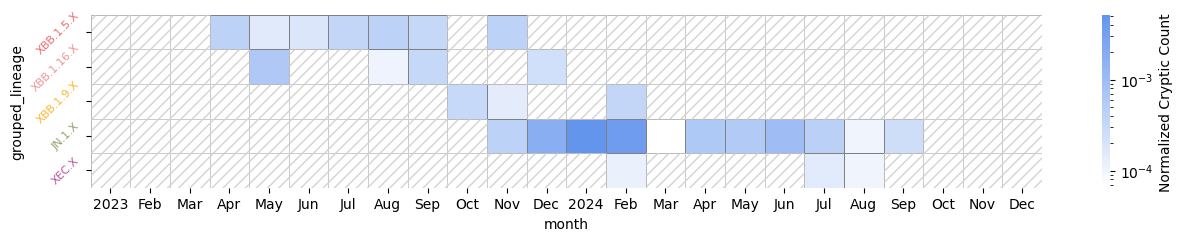

In [3]:
# Plot heatmap of cryptic counts per lineage per month

white_to_purple = mcolors.LinearSegmentedColormap.from_list(
    'white_to_purple', ['white', 'cornflowerblue']
)

fig, ax = plt.subplots(figsize=(13, 2.5))

# Create mask for NaN values
mask = cryptic_pivot.isna()

sns.heatmap(
    cryptic_pivot,
    cmap=white_to_purple, 
    cbar_kws={'label': 'Normalized Cryptic Count'},
    norm=mcolors.LogNorm(),
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

# Add hatching for NaN values
for i in range(len(cryptic_pivot.index)):
    for j in range(len(cryptic_pivot.columns)):
        if mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, 
                                     fill=False, 
                                     edgecolor='lightgray', 
                                     hatch='///', 
                                     linewidth=0.5))

ax.tick_params(axis='y', which='major', labelsize=8)
for label in ax.yaxis.get_ticklabels():
    lineage = label.get_text()
    if lineage in colors_dict:
        label.set_color(colors_dict[lineage])

plt.yticks(rotation=45)
 
plt.tight_layout()
plt.savefig('plots/cryptics_heatmap.pdf', transparent=True)